# Marketing Funnel & Conversion Performance Analysis

## Objective
Analyze customer conversion behavior from marketing campaigns and identify:
- Drop-off points
- High-performing segments
- Factors influencing conversion

## Dataset
Bank Marketing Dataset

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

## 📥 Load Dataset

In [15]:
df=pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\DashBoard\DashBoard PowerBi\Project 7\bank-additional-full.csv",sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


##  Data Understanding

In [18]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


##  Data Cleaning & Preparation

In [21]:
# Convert target variable
df['conversion'] = df['y'].map({'yes': 1, 'no': 0})

# Check missing values
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
conversion        0
dtype: int64

##  Key Performance Indicators (KPIs)

In [24]:
total_contacts = len(df)
total_customers = df['conversion'].sum()
conversion_rate = total_customers / total_contacts

print(f"Total Contacts: {total_contacts}")
print(f"Total Customers: {total_customers}")
print(f"Conversion Rate: {conversion_rate:.2%}")

Total Contacts: 41188
Total Customers: 4640
Conversion Rate: 11.27%


## Funnel Analysis

In [31]:
funnel=pd.DataFrame({
    "Stage":["contacts","Customers"],
    "Count":[total_contacts,total_customers]})
funnel

,Stage,Count
0,contacts,41188
1,Customers,4640


Text(0, 0.5, 'Count')

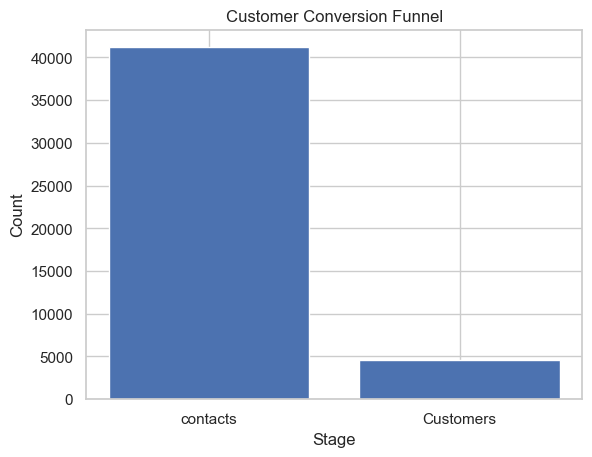

In [39]:
plt.figure()
plt.bar(funnel['Stage'],funnel['Count'])
plt.title("Customer Conversion Funnel")
plt.xlabel("Stage")
plt.ylabel("Count")

## Conversion by Job Category

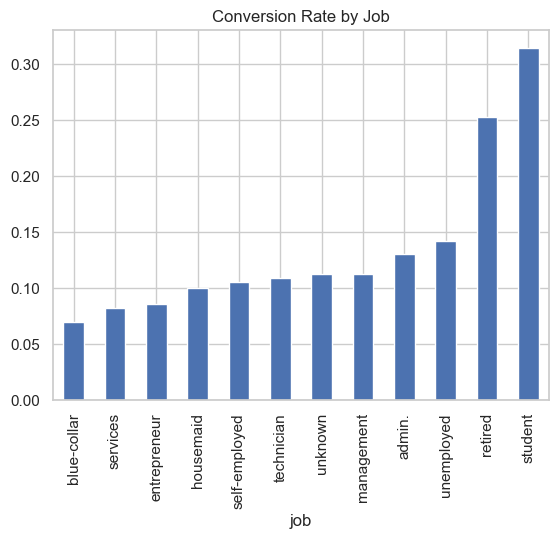

In [60]:
job_conv =df.groupby('job')['conversion'].mean().sort_values()
job_conv.plot(kind='bar')
plt.title("Conversion Rate by Job")
plt.show()

## Conversion by Education Level

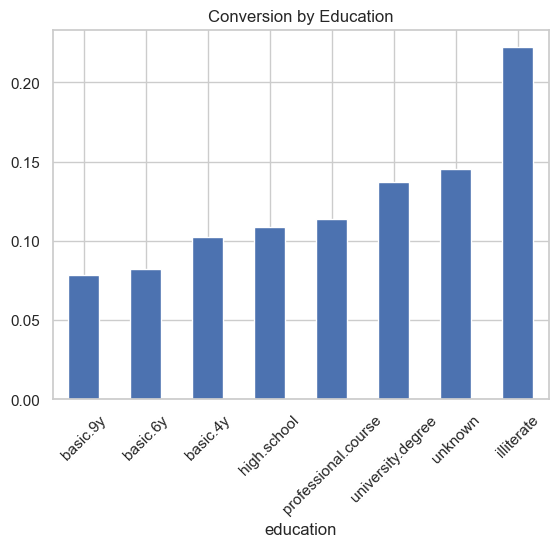

In [77]:
edu_conv=df.groupby('education')['conversion'].mean().sort_values()
edu_conv.plot(kind='bar')
plt.title("Conversion by Education")
plt.xticks(rotation=45)
plt.show()

## Monthly Conversion Trends

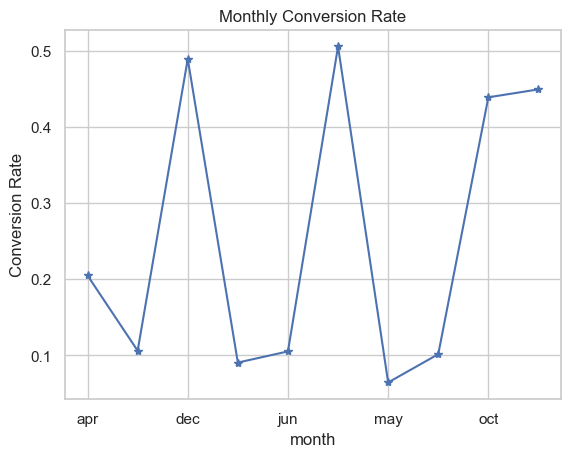

In [86]:
month_conv=df.groupby('month')['conversion'].mean()
month_conv.plot(marker='*')
plt.title("Monthly Conversion Rate")
plt.ylabel("Conversion Rate")
plt.show()

## Previous Campaign Impact

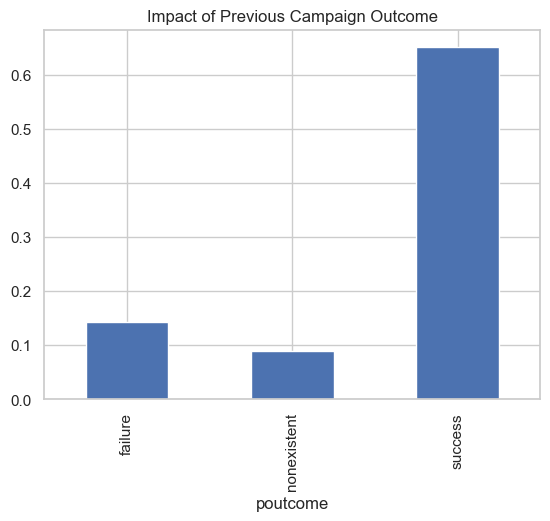

In [95]:
poutcome_conv=df.groupby('poutcome')['conversion'].mean()
poutcome_conv.plot(kind='bar')
plt.title("Impact of Previous Campaign Outcome")
plt.show()

## Call Duration Analysis

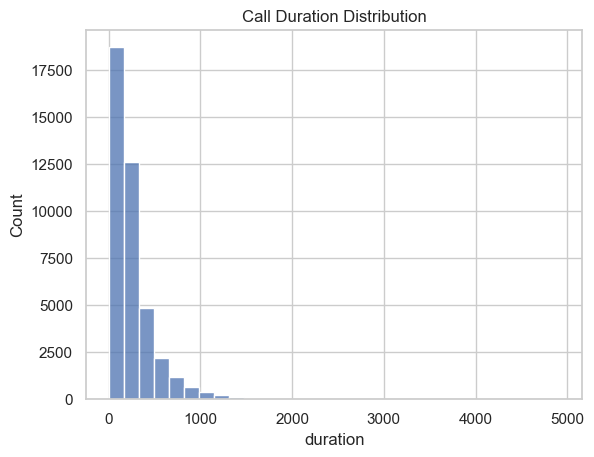

In [108]:
sns.histplot(df['duration'],bins=30)
plt.title("Call Duration Distribution")
plt.show()

## Duration v/s Conversion

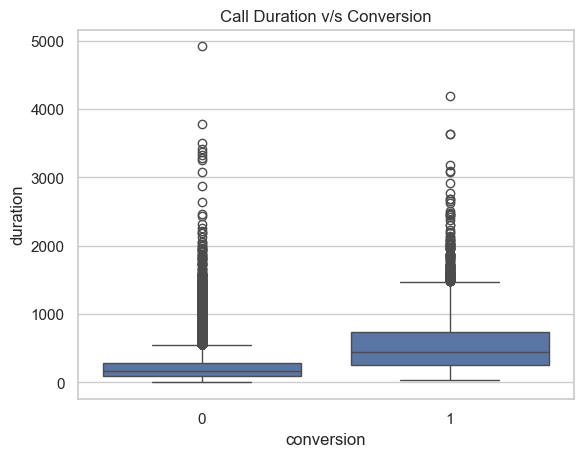

In [115]:
sns.boxplot(x='conversion',y='duration',data=df)
plt.title("Call Duration v/s Conversion")
plt.show()

## Conversion Heatmap (Job v/s Education)

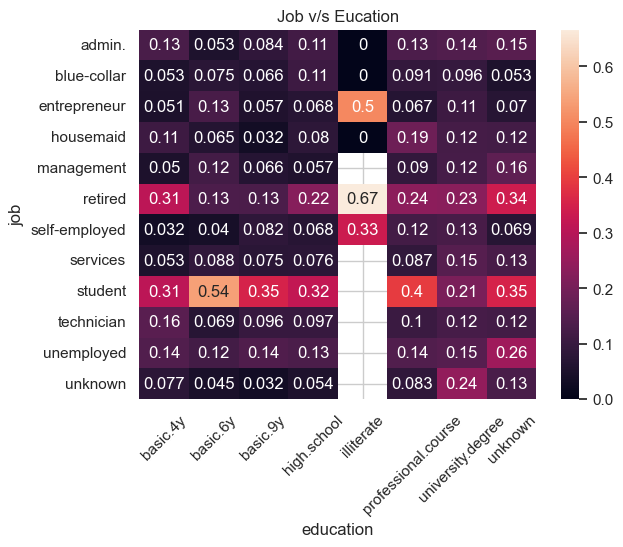

In [126]:
pivot=df.pivot_table(
    values='conversion',
    index='job',
    columns='education',
    aggfunc='mean')
sns.heatmap(pivot,annot=True)
plt.title("Job v/s Eucation")
plt.xticks(rotation=45)
plt.show()

##  Advanced Behavioral Segmentation Analysis
Analyze customer behavior using segmentation and derived metrics.

In [132]:
#creating Duration Buckets
df['duration_bucket']=pd.cut(
    df['duration'],bins=[0,100,300,10000],
    labels=['Low','Medium','High']
)
df[['duration','duration_bucket']].head(10)

,duration,duration_bucket
0,261,Medium
1,149,Medium
2,226,Medium
3,151,Medium
4,307,High
5,198,Medium
6,139,Medium
7,217,Medium
8,380,High
9,50,Low


## Conversion by Duration Category

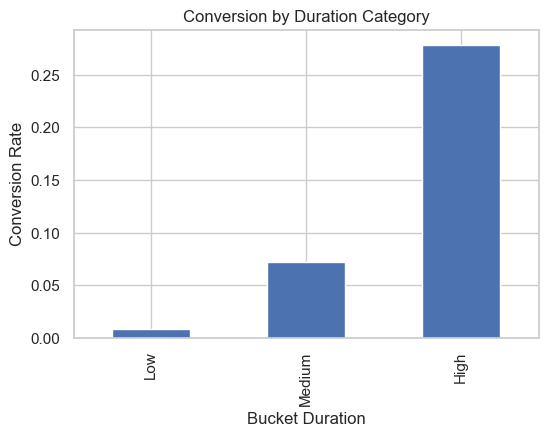

In [145]:
duration_conv=df.groupby('duration_bucket',observed=True)['conversion'].mean()
duration_conv.plot(kind='bar',figsize=(6,4))
plt.title("Conversion by Duration Category")
plt.xlabel("Bucket Duration")
plt.ylabel("Conversion Rate")
plt.show()

## Retargeting v/s New Customer Analysis

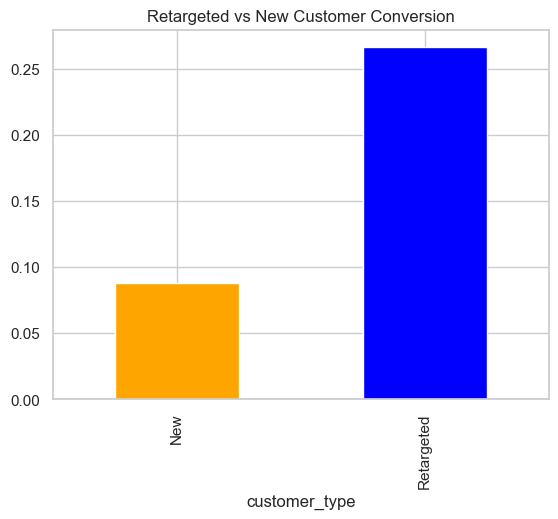

In [148]:
df['customer_type'] = np.where(df['previous'] > 0, 'Retargeted', 'New')

retarget_conv = df.groupby('customer_type')['conversion'].mean()

retarget_conv.plot(kind='bar', color=['orange','blue'])
plt.title("Retargeted vs New Customer Conversion")
plt.show()

##  Campaign Intensity vs Conversion

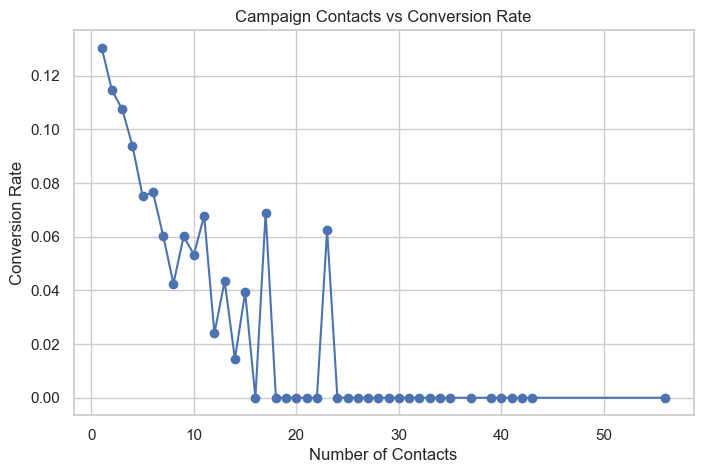

In [151]:
campaign_conv = df.groupby('campaign')['conversion'].mean()

plt.figure(figsize=(8,5))
plt.plot(campaign_conv, marker='o')
plt.title("Campaign Contacts vs Conversion Rate")
plt.xlabel("Number of Contacts")
plt.ylabel("Conversion Rate")
plt.show()

##  Pairwise Feature Relationship (Correlation Heatmap)

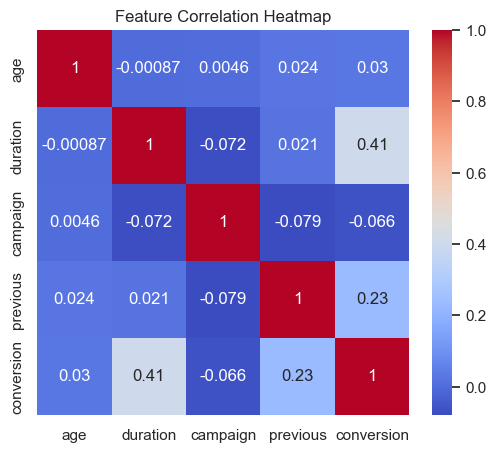

In [154]:
corr = df[['age','duration','campaign','previous','conversion']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

##  Advanced Insights

##  Advanced Insights

##  Conversion Distribution Across Age Groups

df['age_group'] = pd.cut(
    df['age'],
    bins=[18,30,45,60,100],
    labels=['18-30','30-45','45-60','60+']
)

age_conv = df.groupby('age_group',observed=True)['conversion'].mean()

age_conv.plot(kind='bar')
plt.title("Conversion Rate by Age Group")
plt.show()

##  Probability Density of Call Duration (Converted vs Not)

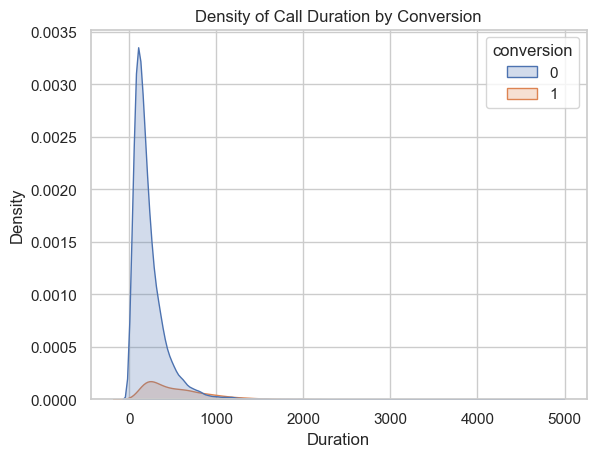

In [164]:
sns.kdeplot(data=df, x='duration', hue='conversion', fill=True)
plt.title("Density of Call Duration by Conversion")
plt.xlabel('Duration')
plt.show()

## Drop-off Simulation Curve

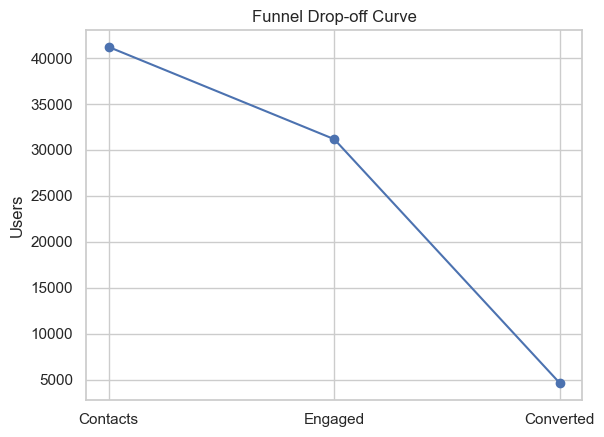

In [167]:
drop_stages = ['Contacts', 'Engaged', 'Converted']
values = [len(df), len(df[df['duration']>100]), df['conversion'].sum()]

plt.plot(drop_stages, values, marker='o')
plt.title("Funnel Drop-off Curve")
plt.ylabel("Users")
plt.show()

##  Customer Risk Segmentation
Identify low probability customers.

In [172]:
risk_customers = df[(df['duration'] < 100) & (df['campaign'] > 3)]
print("High Risk Customers:", len(risk_customers))

High Risk Customers: 2767


##  Conversion by Economic Indicators

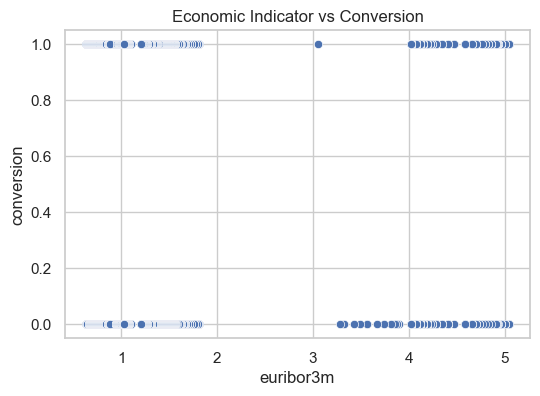

In [175]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='euribor3m', y='conversion', data=df)
plt.title("Economic Indicator vs Conversion")
plt.show()

##  Top Performing Segments

In [178]:
top_segments = df.groupby(['job','education'])['conversion'].mean().sort_values(ascending=False).head(10)
top_segments

job            education          
retired        illiterate             0.666667
student        basic.6y               0.538462
entrepreneur   illiterate             0.500000
student        professional.course    0.395349
               basic.9y               0.353535
               unknown                0.353293
retired        unknown                0.336735
self-employed  illiterate             0.333333
student        high.school            0.319328
retired        basic.4y               0.309883
Name: conversion, dtype: float64